# Store Sales Forecasting Using Temporal Convolutional Neural Network Model

### Imports and Data Preprocessing

In [13]:
import pandas as pd
pd.set_option('display.max_columns', 100)


df = pd.read_csv(r'data/train.csv')

In [14]:
df.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


X input channels with 120 data points each (120 days of historical data) -> model -> X output channels with 16 data points each (16 day forecast)

In [15]:
print(f'Num of Unique Stores: {df['store_nbr'].nunique()}')
print(f'Num of Fmailies: {df['family'].nunique()}')

Num of Unique Stores: 54
Num of Fmailies: 33


In [16]:
# Combine the store number & family name to create unique columns with sales value in each unique combo

df['store_family'] = df.apply(lambda x: f'{x['store_nbr']}_{x['family']}', axis=1)

df.head()

,id,date,store_nbr,family,sales,onpromotion,store_family
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,1_AUTOMOTIVE
1,1,2013-01-01,1,BABY CARE,0.0,0,1_BABY CARE
2,2,2013-01-01,1,BEAUTY,0.0,0,1_BEAUTY
3,3,2013-01-01,1,BEVERAGES,0.0,0,1_BEVERAGES
4,4,2013-01-01,1,BOOKS,0.0,0,1_BOOKS


In [17]:
# Create a pivot to get the aggregated sales for each store_family each day

df_pivoted = df.pivot(index='date', columns='store_family', values='sales')
df_pivoted.head()

store_family,10_AUTOMOTIVE,10_BABY CARE,10_BEAUTY,10_BEVERAGES,10_BOOKS,10_BREAD/BAKERY,10_CELEBRATION,10_CLEANING,10_DAIRY,10_DELI,10_EGGS,10_FROZEN FOODS,10_GROCERY I,10_GROCERY II,10_HARDWARE,10_HOME AND KITCHEN I,10_HOME AND KITCHEN II,10_HOME APPLIANCES,10_HOME CARE,10_LADIESWEAR,10_LAWN AND GARDEN,10_LINGERIE,"10_LIQUOR,WINE,BEER",10_MAGAZINES,10_MEATS,10_PERSONAL CARE,10_PET SUPPLIES,10_PLAYERS AND ELECTRONICS,10_POULTRY,10_PREPARED FOODS,10_PRODUCE,10_SCHOOL AND OFFICE SUPPLIES,10_SEAFOOD,11_AUTOMOTIVE,11_BABY CARE,11_BEAUTY,11_BEVERAGES,11_BOOKS,11_BREAD/BAKERY,11_CELEBRATION,11_CLEANING,11_DAIRY,11_DELI,11_EGGS,11_FROZEN FOODS,11_GROCERY I,11_GROCERY II,11_HARDWARE,11_HOME AND KITCHEN I,11_HOME AND KITCHEN II,...,8_HOME AND KITCHEN II,8_HOME APPLIANCES,8_HOME CARE,8_LADIESWEAR,8_LAWN AND GARDEN,8_LINGERIE,"8_LIQUOR,WINE,BEER",8_MAGAZINES,8_MEATS,8_PERSONAL CARE,8_PET SUPPLIES,8_PLAYERS AND ELECTRONICS,8_POULTRY,8_PREPARED FOODS,8_PRODUCE,8_SCHOOL AND OFFICE SUPPLIES,8_SEAFOOD,9_AUTOMOTIVE,9_BABY CARE,9_BEAUTY,9_BEVERAGES,9_BOOKS,9_BREAD/BAKERY,9_CELEBRATION,9_CLEANING,9_DAIRY,9_DELI,9_EGGS,9_FROZEN FOODS,9_GROCERY I,9_GROCERY II,9_HARDWARE,9_HOME AND KITCHEN I,9_HOME AND KITCHEN II,9_HOME APPLIANCES,9_HOME CARE,9_LADIESWEAR,9_LAWN AND GARDEN,9_LINGERIE,"9_LIQUOR,WINE,BEER",9_MAGAZINES,9_MEATS,9_PERSONAL CARE,9_PET SUPPLIES,9_PLAYERS AND ELECTRONICS,9_POULTRY,9_PREPARED FOODS,9_PRODUCE,9_SCHOOL AND OFFICE SUPPLIES,9_SEAFOOD
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2013-01-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.000,0.00000,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.000
2013-01-02,3.0,0.0,6.0,396.0,0.0,151.0,0.0,1110.0,101.0,276.0,57.0,41.164,2579.0,8.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,6.0,0.0,291.14000,223.0,0.0,0.0,146.78400,26.0,0.0,0.0,3.0,12.0,0.0,7.0,3443.0,0.0,763.0,0.0,3260.0,296.0,527.295,140.0,57.771000,7736.0,15.0,3.0,0.0,0.0,...,0.0,0.0,0.0,0.0,18.0,50.0,80.0,0.0,630.400,443.0,0.0,0.0,364.081,266.08800,0.0,0.0,72.284,5.0,0.0,6.0,1309.0,0.0,1001.0,0.0,2624.0,473.0,725.902,237.0,88.545,7718.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,18.0,22.0,0.0,374.531,482.0,0.0,0.0,651.292,83.0,0.0,0.0,29.214
2013-01-03,2.0,0.0,3.0,399.0,0.0,129.0,0.0,970.0,113.0,269.0,38.0,14.470,1984.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,2.0,0.0,279.74298,169.0,0.0,0.0,148.31700,10.0,0.0,0.0,13.0,8.0,0.0,3.0,1911.0,0.0,658.0,0.0,2282.0,173.0,322.415,74.0,40.714000,5172.0,5.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,23.0,96.0,0.0,554.311,307.0,0.0,0.0,277.600,153.62400,0.0,0.0,43.441,22.0,0.0,6.0,1047.0,0.0,747.0,0.0,1781.0,231.0,414.087,158.0,45.273,4547.0,17.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,37.0,0.0,400.863,372.0,0.0,0.0,509.496,66.0,0.0,0.0,25.000
2013-01-04,2.0,0.0,4.0,460.0,0.0,105.0,0.0,669.0,66.0,92.0,22.0,10.691,1565.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,0.0,139.16600,119.0,0.0,0.0,111.15900,4.0,0.0,0.0,2.0,5.0,0.0,1.0,2585.0,0.0,580.0,0.0,2067.0,192.0,316.786,39.0,53.899002,4678.0,11.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,25.0,189.0,0.0,1170.334,238.0,0.0,0.0,309.340,238.12900,0.0,0.0,49.508,0.0,0.0,3.0,986.0,0.0,513.0,0.0,1383.0,205.0,238.125,83.0,3.484,3564.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,7.0,54.0,0.0,310.878,324.0,0.0,0.0,332.672,57.0,0.0,0.0,11.000
2013-01-05,0.0,0.0,3.0,624.0,0.0,112.0,0.0,1093.0,88.0,194.0,43.0,13.891,2544.0,5.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,26.0,0.0,247.29800,270.0,0.0,0.0,135.59601,3.0,0.0,0.0,2.0,7.0,0.0,10.0,2352.0,0.0,646.0,0.0,2890.0,260.0,395.425,67.0,42.841000,6107.0,17.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,25.0,186.0,0.0,608.860,431.0,0.0,0.0,317.585,326.60602,0.0,0.0,57.611,27.0,0.0,9.0,1415.0,0.0,631

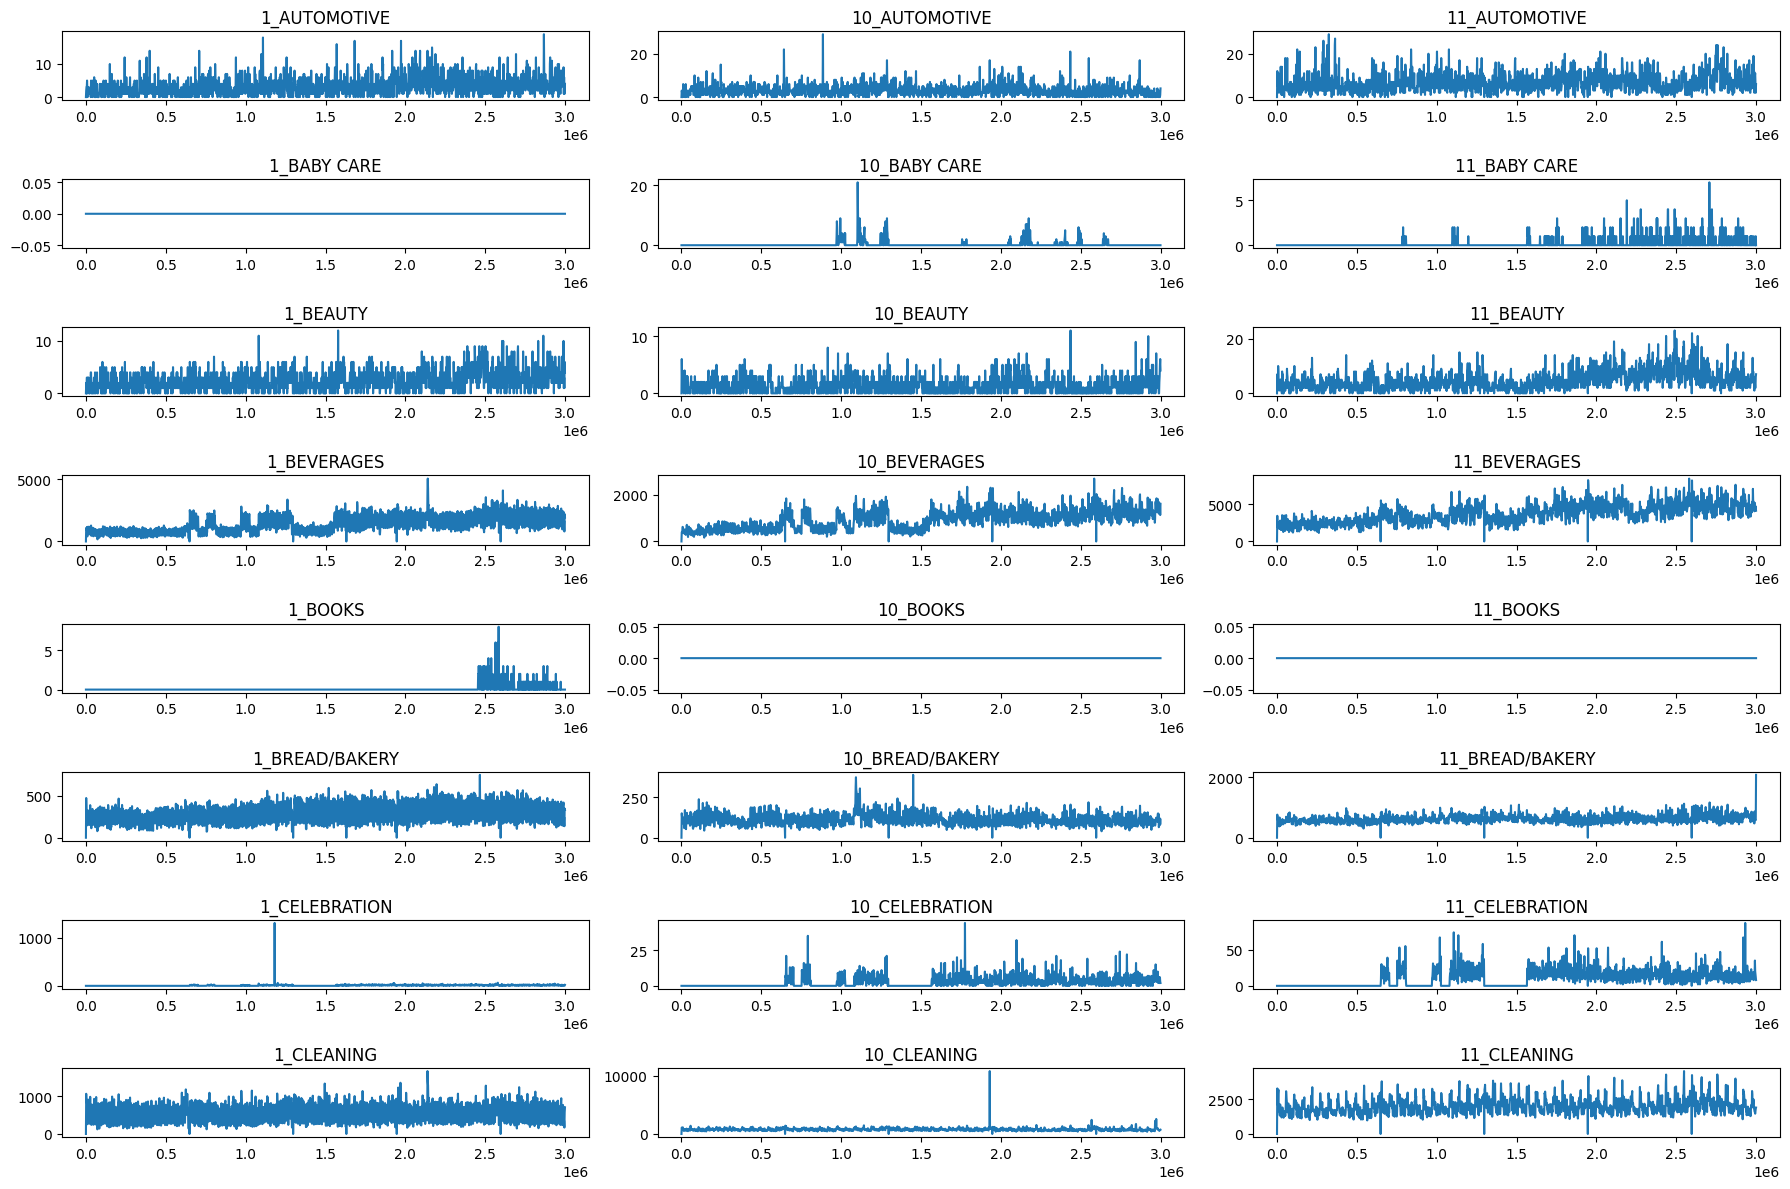

In [18]:
# Visualize the different time series channels
import matplotlib.pyplot as plt

fig, axs = plt.subplots(8, 3, figsize=(18,12))

for i in range(8):
    for j in range(3):
        ax = axs[i][j]
        ax.plot(df[(df.family == df['family'].unique()[i]) & (df.store_nbr == df['store_nbr'].unique()[j])].sales)
        ax.set_title(f'{df.store_nbr.unique()[j]}_{df.family.unique()[i]}')

plt.tight_layout()

In [20]:
# Scale the Data so the CNN can take it without traeting features more favorabley because they have larger values
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

train_size = int(0.8 * len(df_pivoted))
# Because it is a time series data set, no shuffling of data needed because we want to train on the earlier dates to test with the later dates after
# If this was a binary classification algo, then we would need to shuffle
train_data = df_pivoted.iloc[:train_size] # First 80% of data used as train dataset
test_data  = df_pivoted.iloc[train_size:] # Last 20% of data used as test dataset

train_data_scaled = scaler.fit_transform(train_data) # Learn the scale and transform using the scaling data
test_data_scaled = scaler.transform(test_data) # Not going to learn test data (fit), just apply the scale

In [22]:
# Helper function to turn into X and Y arrays for training

import numpy as np

def create_X_y(data, input_length, output_length):
    X, y = [], []

    for i in range(len(data) - input_length - output_length): # Leave room for 120 input records and 16 output records to test
        X.append(data[i:i+input_length])
        y.append(data[i+input_length:i+input_length+output_length])

    return np.array(X), np.array(y)

In [27]:
# Get X_train and y_train datasets with the function

X_train, y_train = create_X_y(train_data_scaled, 120, 16)
X_test, y_test = create_X_y(test_data_scaled, 120, 16)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(1211, 120, 1782) (1211, 16, 1782)
(201, 120, 1782) (201, 16, 1782)


Have 1,211 data points (packs), 120 days to look at, 1782 of different time series channel combos, which produces 16 days worth of outputs for the different time series channel combos

In [ ]:
# Turn these arrays into a torch compatible format (pytorch tensors), the tensor datasets, then data loaders
import torch

# Cant use CUDA because running on a MacBook Pro M4 Chip Series (only NVIDIA GPU can use CUDA)
# Use MPS (Metal Performance Shaders) to access the GPU on MacBook

# Check if MPS is available
print(f'MPS available?: {torch.backends.mps.is_available()}')   # True on M-series Macs
print(f'PyTorch Version Built with MPS Support?: {torch.backends.mps.is_built()}\n')       # confirms PyTorch was built with MPS support

# Use GPU if MPS is available else use CPU

# Run for each array (X_train, y_train, X_test, y_test)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu") # If GPU available then use

X_train_tensor = torch.FloatTensor(X_train).to(device) # pass the X_train np array
print(f'X_train_tensor device running on: {X_train_tensor.device}')  # mps:0

X_test_tensor = torch.FloatTensor(X_test).to(device) # pass the X_test np array
print(f'X_test_tensor device running on: {X_test_tensor.device}')  # mps:0

y_train_tensor = torch.FloatTensor(y_train).to(device) # pass the y_train np array
print(f'y_train_tensor device running on: {y_train_tensor.device}')  # mps:0

y_test_tensor = torch.FloatTensor(y_test).to(device) # pass the y_test np array
print(f'y_test_tensor device running on: {y_test_tensor.device}')  # mps:0

MPS available?: True
PyTorch Version Built with MPS Support?: True

X_train_tensor device running on: mps:0
X_test_tensor device running on : mps:0
y_train_tensor device running on: mps:0
y_test_tensor device running on : mps:0


In [42]:
# Turn the tensors into tensor datasets and data loaders

from torch.utils.data import TensorDataset, DataLoader

# Create train dataset and train loader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True) # Shuffle for training to increase variety

# Create test dataset and test loader
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False ) # Don't shuffle for test because just doing inference (predicting not training model)

### Build and Train Model

In [54]:
import torch.nn as nn
import torch.nn.functional as F


# BUILD TEMPORAL CONVOLUTIONAL NETWORK Model (TCNModel)
class TCNModel(nn.Module):
    def __init__(self):
        super().__init__()

        # Simple Convolutional Layer, which takes in data and produces 64 kernels
        # Kernels are like a window that slides over data
        # We will be doing a 1 Dimension Convolution, so the kernels are just sliding across the time series
        # Can do it in parallel because using CNN



        # LAYER 1
        # Input channels: hard coded 33 * 54 because we have 33 unique families in 54 unique stores, 1782 different time series to have CNN predict on / create outputs
        # Output Channels: Using 64 for now, not totally sure (have LLM explain with our context)
        # Kernel size: 3 for our scenario (not totally sure why either, need LLM to explain wiht our context. I think because 3 elements in each array)
        # Padding: have some arbitray padding that can outside of the scope of your input channel to create more outputs (see the pictures in the animations below)
        # Dilation: Spreading out your focus, the kernel splits up the aggregation of input channel (see the pictures in the animations below). 
        # We will always double the dialation and padding over the following layers
        self.conv1 = nn.Conv1d(in_channels=33*54, out_channels=64, kernel_size=3, padding=2, dilation=1)

        # LAYER 2
        # Input channels: 64 now because Layer 1 outputs 64 channels
        # Output Channels: 64 Still
        # Kernel size: 3 Still
        # Padding: Double from 2 to 4
        # Dilation: Double from 1 to 2
        self.conv2 = nn.Conv1d(in_channels=64, out_channels=64, kernel_size=3, padding=4, dilation=2)

        # LAYER 3
        # Input channels: 64 again because Layer 2 outputs 64 channels
        # Output Channels: 64 Still
        # Kernel size: 3 Still
        # Padding: Double from 4 to 8
        # Dilation: Double from 2 to 4
        self.conv3 = nn.Conv1d(in_channels=64, out_channels=64, kernel_size=3, padding=8, dilation=4)


        # Linear Layer (fully connected layer)
        # 64 input channels
        # Produce 16 days outputs for 33 * 54 channels (1782)
        self.fc = nn.Linear(in_features=64, out_features=16*33*54)


    # Now we have the archuecture of the CNN, we need to feed the data through it

    def forward(self, x):
        # Swap the 2nd and 3rd dimension
        x = x.transpose(1, 2) # 2nd and 3rd element in array, so swapping 120 days to the last element of array with the 1782 total store/family combos to the 2nd element of array

        # Break linearity with acitivation layer
        # Using RELU Acivation function
        # Get rid of the padding to get the same temporal length as the beginning
        x = F.relu(self.conv1(x[:,:,:-2])) # First layer has a padding of 2, so revert back two lengths
        x = F.relu(self.conv2(x[:,:,:-4])) # Second layer has a padding of 4, so revert back two lengths
        x = F.relu(self.conv3(x[:,:,:-8])) # Third layer has a padding of 8, so revert back two lengths

        # Now return the fully connected layers
        # View puts it in the format we want again, not just the one huge unstructured number (-1 batch size inferred automatically, 16 days, for each day have 33*54 channels)
        return self.fc(x[:,:,-1]).view(-1, 16, 33*54) 

In [55]:
# Instantiations
model = TCNModel().to(device) # Initialize the Model and send to GPU using device GPU var we created earlier
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) # lr = Learning Rate
criterion = nn.MSELoss() # Use Mean Squared Error Loss as the criterion for the model performance gain

In [ ]:
# Training Loop Logic

for epoch in range(30): # 30 is enough, dont go too far because you will overfit
    model.train() # Put model into train mode
    epoch_loss = 0 

    for X_batch, y_batch in train_loader: # 32 was defined in the train loader
        # Calculate the loss by back propgating, taking a step with the optimizer
        optimizer.zero_grad()

        y_pred = model(X_batch)
        loss = torch.sqrt(criterion(y_pred, y_batch)) # Use the RMSE instead of MSE 
        loss.backward() 

        optimizer.step()

        epoch_loss += loss.item() # Update the loss for each batch ran

    # Print occasionally
    if (epoch+1) % 5 == 0:
        print(f'Epoch {epoch+1}, Loss: {epoch_loss/len(train_loader)}')

Epoch 5, Loss: 0.783584304546055
Epoch 10, Loss: 0.740370606121264
Epoch 15, Loss: 0.7187136505779467
Epoch 20, Loss: 0.7051313205769187
Epoch 25, Loss: 0.6948719714817247
Epoch 30, Loss: 0.6859634032374934


Can see the loss decrease over the 30 Epochs

# Test on the Validation set we put to the side at the beginning

In [57]:
# Put model on eval mode
model.eval()

with torch.no_grad():
    test_pred = model(X_test_tensor)
    test_loss = torch.sqrt(criterion(test_pred, y_test_tensor))
    print(test_loss)

tensor(171.8581, device='mps:0')


The loss is a lot higher in this eval set because there is a huge outlier, can ignore for now but worht investigating for a model in production

# Full Dataset Training (same thing as before but no dataset splitting from train.csv)

In [58]:
full_data_scaled = scaler.fit_transform(df_pivoted)

# No split anymore, just create X and y
X_full, y_full = create_X_y(full_data_scaled, 120, 16)

X_full_tensor = torch.FloatTensor(X_full).to(device)
y_full_tensor = torch.FloatTensor(y_full).to(device)

full_dataset = TensorDataset(X_full_tensor, y_full_tensor)
full_loader = DataLoader(full_dataset, batch_size = 32, shuffle=True) # Training the model on the whole set

# Final Model
final_model = TCNModel().to(device) # Initialize the Model and send to GPU using device GPU var we created earlier
optimizer = torch.optim.Adam(final_model.parameters(), lr=0.001) # lr = Learning Rate
criterion = nn.MSELoss() # Use Mean Squared Error Loss as the criterion for the model performance gain

In [59]:
# Training Loop Logic for Final Model

for epoch in range(30): # 30 is enough, dont go too far because you will overfit
    final_model.train() # Put model into train mode
    epoch_loss = 0 

    for X_batch, y_batch in full_loader: # 32 was defined in the train loader
        # Calculate the loss by back propgating, taking a step with the optimizer
        optimizer.zero_grad()

        y_pred = final_model(X_batch)
        loss = torch.sqrt(criterion(y_pred, y_batch)) # Use the RMSE instead of MSE 
        loss.backward() 

        optimizer.step()

        epoch_loss += loss.item() # Update the loss for each batch ran

    # Print occasionally
    if (epoch+1) % 5 == 0:
        print(f'Epoch {epoch+1}, Loss: {epoch_loss/len(full_loader)}')

Epoch 5, Loss: 0.7912048150082024
Epoch 10, Loss: 0.7481381528231562
Epoch 15, Loss: 0.7288495898246765
Epoch 20, Loss: 0.7167119590603576
Epoch 25, Loss: 0.7074027438553012
Epoch 30, Loss: 0.7014310603239098


# Final Test on the last sequence (120 days) and do a prediction on that for the next 16 days

In [ ]:
# Put final model in eval mode
final_model.eval()

with torch.no_grad():
    # In the training data, we can use the last 120 days to predict the next 16 days
    # Unsqueeze to additional one dimension
    last_sequence = torch.FloatTensor(full_data_scaled[-120:]).unsqueeze(0).to(device) 
    predictions = final_model(last_sequence)

In [62]:
# Show the final predictions for the 16 days on all the channels
predictions

tensor([[[-0.5753, -0.3342,  0.2268,  ...,  0.4541,  0.2147, -0.1093],
         [-0.6519, -0.4974,  0.3517,  ...,  0.1732,  0.2091, -0.1185],
         [-0.4075, -0.3792,  0.3678,  ...,  0.1423,  0.4829, -0.2327],
         ...,
         [-0.4359, -0.1480,  0.6492,  ...,  1.5619,  1.9897,  0.0879],
         [-0.5327, -0.3942,  0.3319,  ...,  0.7932,  2.4023,  0.3594],
         [-0.6162, -0.2301,  0.4491,  ...,  0.4506,  2.2447, -0.0306]]],
       device='mps:0')

In [64]:
# Now we need to bring it back to the CPU / Numpy, we need to squeeze it again to remove additoinal dimension
# Inverse scale them, remove negative values, take final data and write it to a CSV

predictions = predictions.to('cpu').numpy().squeeze(0) # Bring tensor back to CPU so we can put it back into numpy array  
predictions = scaler.inverse_transform(predictions) # Inverse transform the scaled data
predictions = np.maximum(predictions, 0) # If negative number, turn it to 0 because we dont have negative sales it was just negative from the StandardScaler

In [66]:
# Show the cleaned prediciton data for the 16 days across all channels
predictions

array([[1.55574417e+00, 0.00000000e+00, 1.69201231e+00, ...,
        1.36884814e+03, 1.08352356e+01, 1.58594446e+01],
       [1.35225570e+00, 0.00000000e+00, 1.86770391e+00, ...,
        1.12156067e+03, 1.07096472e+01, 1.57728443e+01],
       [2.00112844e+00, 0.00000000e+00, 1.89045811e+00, ...,
        1.09437183e+03, 1.68117199e+01, 1.47028084e+01],
       ...,
       [1.92576134e+00, 1.03777096e-01, 2.28639722e+00, ...,
        2.34390283e+03, 5.03893738e+01, 1.77085876e+01],
       [1.66895258e+00, 0.00000000e+00, 1.83992505e+00, ...,
        1.66731152e+03, 5.95825424e+01, 2.02541599e+01],
       [1.44708669e+00, 9.50062275e-03, 2.00486040e+00, ...,
        1.36570276e+03, 5.60713921e+01, 1.65975094e+01]],
      shape=(16, 1782), dtype=float32)

In [67]:
# Put the predicted next 16 days data into a DF for the test data

test_df = pd.read_csv('data/test.csv')

In [68]:
# Create the combined column for test dataset like we did at the beginning
test_df['store_family'] = test_df.apply(lambda x: f'{x['store_nbr']}_{x['family']}', axis=1)

In [ ]:
# Get unique dates from test dataset (The 16 dates) that we will map our predictions to
dates = sorted(test_df['date'].unique())

In [70]:
dates

['2017-08-16',
 '2017-08-17',
 '2017-08-18',
 '2017-08-19',
 '2017-08-20',
 '2017-08-21',
 '2017-08-22',
 '2017-08-23',
 '2017-08-24',
 '2017-08-25',
 '2017-08-26',
 '2017-08-27',
 '2017-08-28',
 '2017-08-29',
 '2017-08-30',
 '2017-08-31']

In [72]:
# Create dataframe using the dates provided in test.csv, then we put our predicted values in there for each channel column
pred_df = pd.DataFrame(predictions, index=dates,columns=df_pivoted.columns)
pred_df

store_family,10_AUTOMOTIVE,10_BABY CARE,10_BEAUTY,10_BEVERAGES,10_BOOKS,10_BREAD/BAKERY,10_CELEBRATION,10_CLEANING,10_DAIRY,10_DELI,10_EGGS,10_FROZEN FOODS,10_GROCERY I,10_GROCERY II,10_HARDWARE,10_HOME AND KITCHEN I,10_HOME AND KITCHEN II,10_HOME APPLIANCES,10_HOME CARE,10_LADIESWEAR,10_LAWN AND GARDEN,10_LINGERIE,"10_LIQUOR,WINE,BEER",10_MAGAZINES,10_MEATS,10_PERSONAL CARE,10_PET SUPPLIES,10_PLAYERS AND ELECTRONICS,10_POULTRY,10_PREPARED FOODS,10_PRODUCE,10_SCHOOL AND OFFICE SUPPLIES,10_SEAFOOD,11_AUTOMOTIVE,11_BABY CARE,11_BEAUTY,11_BEVERAGES,11_BOOKS,11_BREAD/BAKERY,11_CELEBRATION,11_CLEANING,11_DAIRY,11_DELI,11_EGGS,11_FROZEN FOODS,11_GROCERY I,11_GROCERY II,11_HARDWARE,11_HOME AND KITCHEN I,11_HOME AND KITCHEN II,...,8_HOME AND KITCHEN II,8_HOME APPLIANCES,8_HOME CARE,8_LADIESWEAR,8_LAWN AND GARDEN,8_LINGERIE,"8_LIQUOR,WINE,BEER",8_MAGAZINES,8_MEATS,8_PERSONAL CARE,8_PET SUPPLIES,8_PLAYERS AND ELECTRONICS,8_POULTRY,8_PREPARED FOODS,8_PRODUCE,8_SCHOOL AND OFFICE SUPPLIES,8_SEAFOOD,9_AUTOMOTIVE,9_BABY CARE,9_BEAUTY,9_BEVERAGES,9_BOOKS,9_BREAD/BAKERY,9_CELEBRATION,9_CLEANING,9_DAIRY,9_DELI,9_EGGS,9_FROZEN FOODS,9_GROCERY I,9_GROCERY II,9_HARDWARE,9_HOME AND KITCHEN I,9_HOME AND KITCHEN II,9_HOME APPLIANCES,9_HOME CARE,9_LADIESWEAR,9_LAWN AND GARDEN,9_LINGERIE,"9_LIQUOR,WINE,BEER",9_MAGAZINES,9_MEATS,9_PERSONAL CARE,9_PET SUPPLIES,9_PLAYERS AND ELECTRONICS,9_POULTRY,9_PREPARED FOODS,9_PRODUCE,9_SCHOOL AND OFFICE SUPPLIES,9_SEAFOOD
2017-08-16,1.555744,0.000000,1.692012,1040.593140,0.068899,84.623207,3.847270,789.343323,312.606781,221.752640,26.385771,63.796097,2279.667969,6.720138,0.131458,11.470552,7.697092,0.124413,162.135315,2.161266,0.000000,0.129690,14.118180,0.594574,133.420868,162.531769,0.903987,3.454903,140.589676,18.781950,211.871841,1.640975,1.982334,6.085034,0.365423,4.590700,4116.816895,0.000000,564.434326,12.529715,1668.211182,614.362549,463.603577,156.600540,136.640564,7099.790039,34.083786,0.662503,26.635565,20.498316,...,40.638523,1.027366,386.723236,28.257887,44.504906,20.958132,160.718735,13.226483,434.656403,332.705750,16.588552,20.235363,596.672852,145.006378,6921.859375,0.565578,41.682755,12.506858,0.187663,7.747900,2811.536621,0.046927,473.054108,16.520866,1391.012939,836.958862,468.441010,161.364548,208.125732,5182.326660,15.145569,0.834372,32.862820,36.427307,0.263934,397.880127,13.711973,7.112535,5.718241,51.651237,2.803947,315.939606,360.892151,7.538345,9.375044,352.237244,98.464020,1368.848145,10.835236,15.859445
2017-08-17,1.352256,0.000000,1.867704,1004.872864,0.046761,82.753357,2.685227,693.973572,231.283279,221.618805,23.842979,64.151505,2205.911621,5.861457,0.433552,12.618557,7.930607,0.144163,141.187027,0.876651,0.000000,0.303834,14.679041,0.472595,178.175018,151.073303,0.518338,3.209873,140.009003,15.461712,205.864380,2.027834,1.657677,4.909807,0.218668,4.077693,4063.860840,0.000000,589.146545,9.063685,1558.981323,537.460327,446.556671,132.288406,139.794342,6092.675781,33.598011,0.868073,24.152988,19.772997,...,39.642296,0.476256,268.401886,18.649645,29.450886,22.577417,147.598053,13.215919,363.537231,231.885437,15.514477,17.368540,442.077667,132.413849,3350.880371,0.545832,29.262251,11.529310,0.151552,6.840411,2565.566162,0.000000,500.731995,13.781912,1442.270996,616.066772,469.987671,159.609497,176.213989,4895.128906,19.689808,1.065480,37.285118,33.903641,0.255929,347.803345,12.263828,5.114024,5.768644,69.397942,2.702969,484.744659,362.217102,6.253037,8.080468,341.404022,88.579323,1121.560669,10.709647,15.772844
2017-08-18,2.001128,0.000000,1.890458,1046.965942,0.016801,71.887024,2.328851,741.886536,207.507065,243.467468,29.239286,70.457016,2230.824463,8.268227,0.265153,12.712732,7.501867,0.085890,121.437370,0.000000,0.002211,0.000000,17.961679,0.376352,117.903732,130.627899,0.435329,3.566917,146.547684,17.170099,198.943359,1.976431,1.117196,5.970328,0.442394,3.316031,4590.422852,0.000000,523.984314,15.884594,1622.383545,466.890991,517.147705,192.229065,145.781342,6134.021973,32.899231,0.7

In [ ]:
# Need to map to an ID now because that is how we received the data / how it is accepted

# First use stack to unpivot back to original format with an index (not date as index)

pred_long = pred_df.stack().reset_index()
pred_long.columns = ['date', 'store_family', 'sales']

In [76]:
# Map the ID on the store_family and date value by joining the predictions back to the original test.csv dataframe  
submission_df = test_df.merge(pred_long, on=['date','store_family'], how='left')

In [79]:
# Notice how we created the sales column by 'stack' method for our predicted values and defining the column as sales
# There was no sales column in the test.csv dataset because we needed to create it from our model
submission_df[['id', 'sales']]

,id,sales
0,3000888,4.332467
1,3000889,0.000000
2,3000890,3.711947
3,3000891,2313.434082
4,3000892,0.139894
...,...,...
28507,3029395,388.471497
28508,3029396,104.596405
28509,3029397,1365.702759
28510,3029398,56.071392


In [80]:
# Now export the ID and sales only to submit to Kaggle 
submission_df[['id', 'sales']].to_csv('submission.csv', index=False)

There are some ways to make it even more accurate through feature engineering, using different models, adding recurrent layers, etc. But for a first model this is pretty strong

# Some additional support to different pieces of this project below

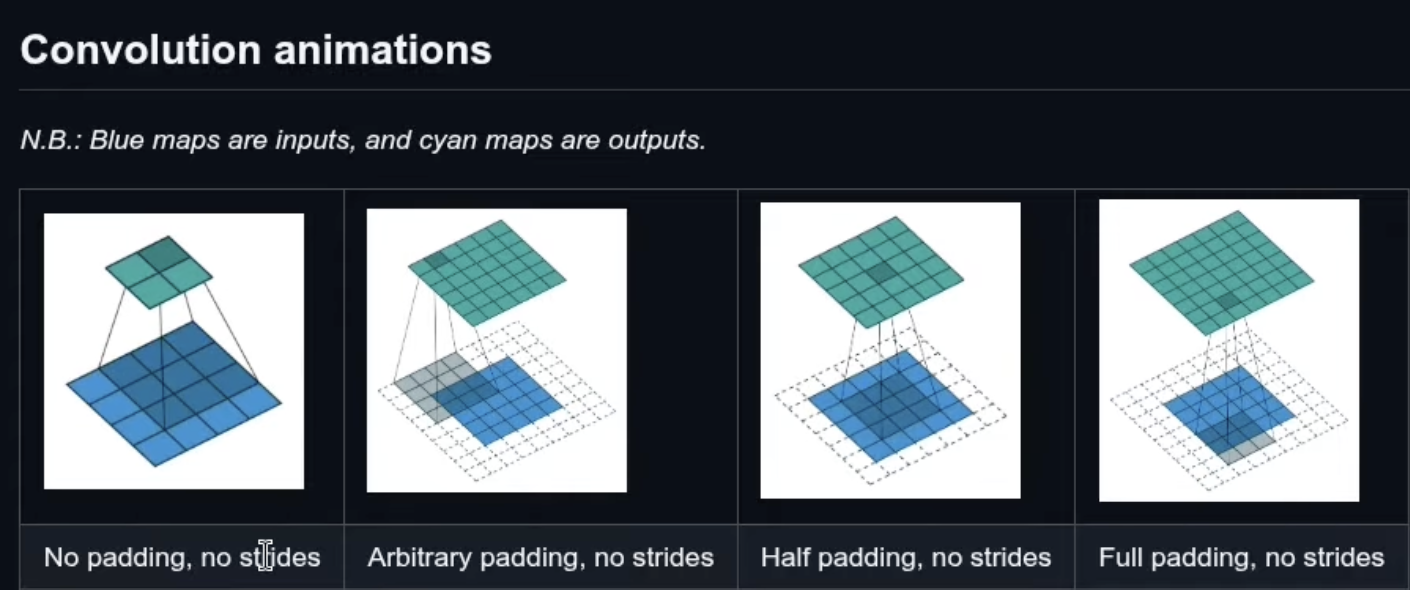

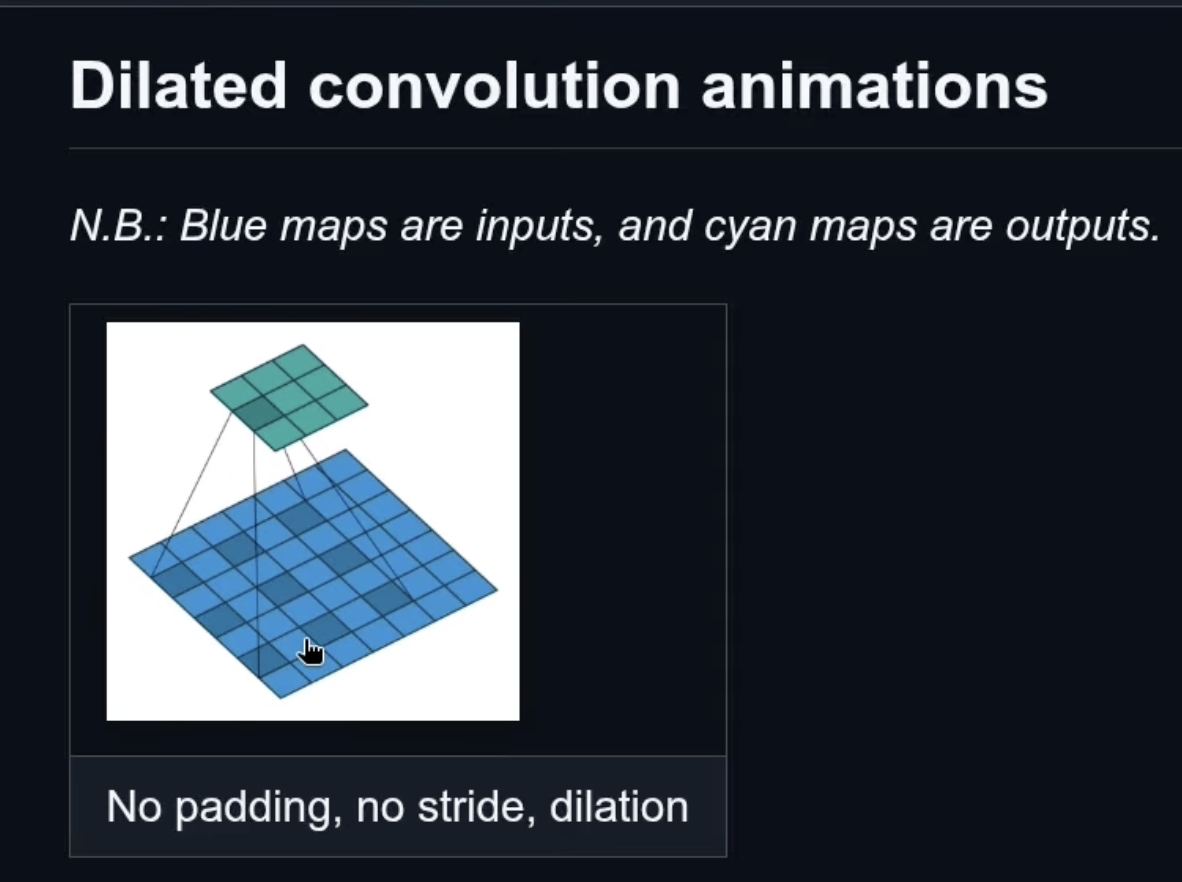

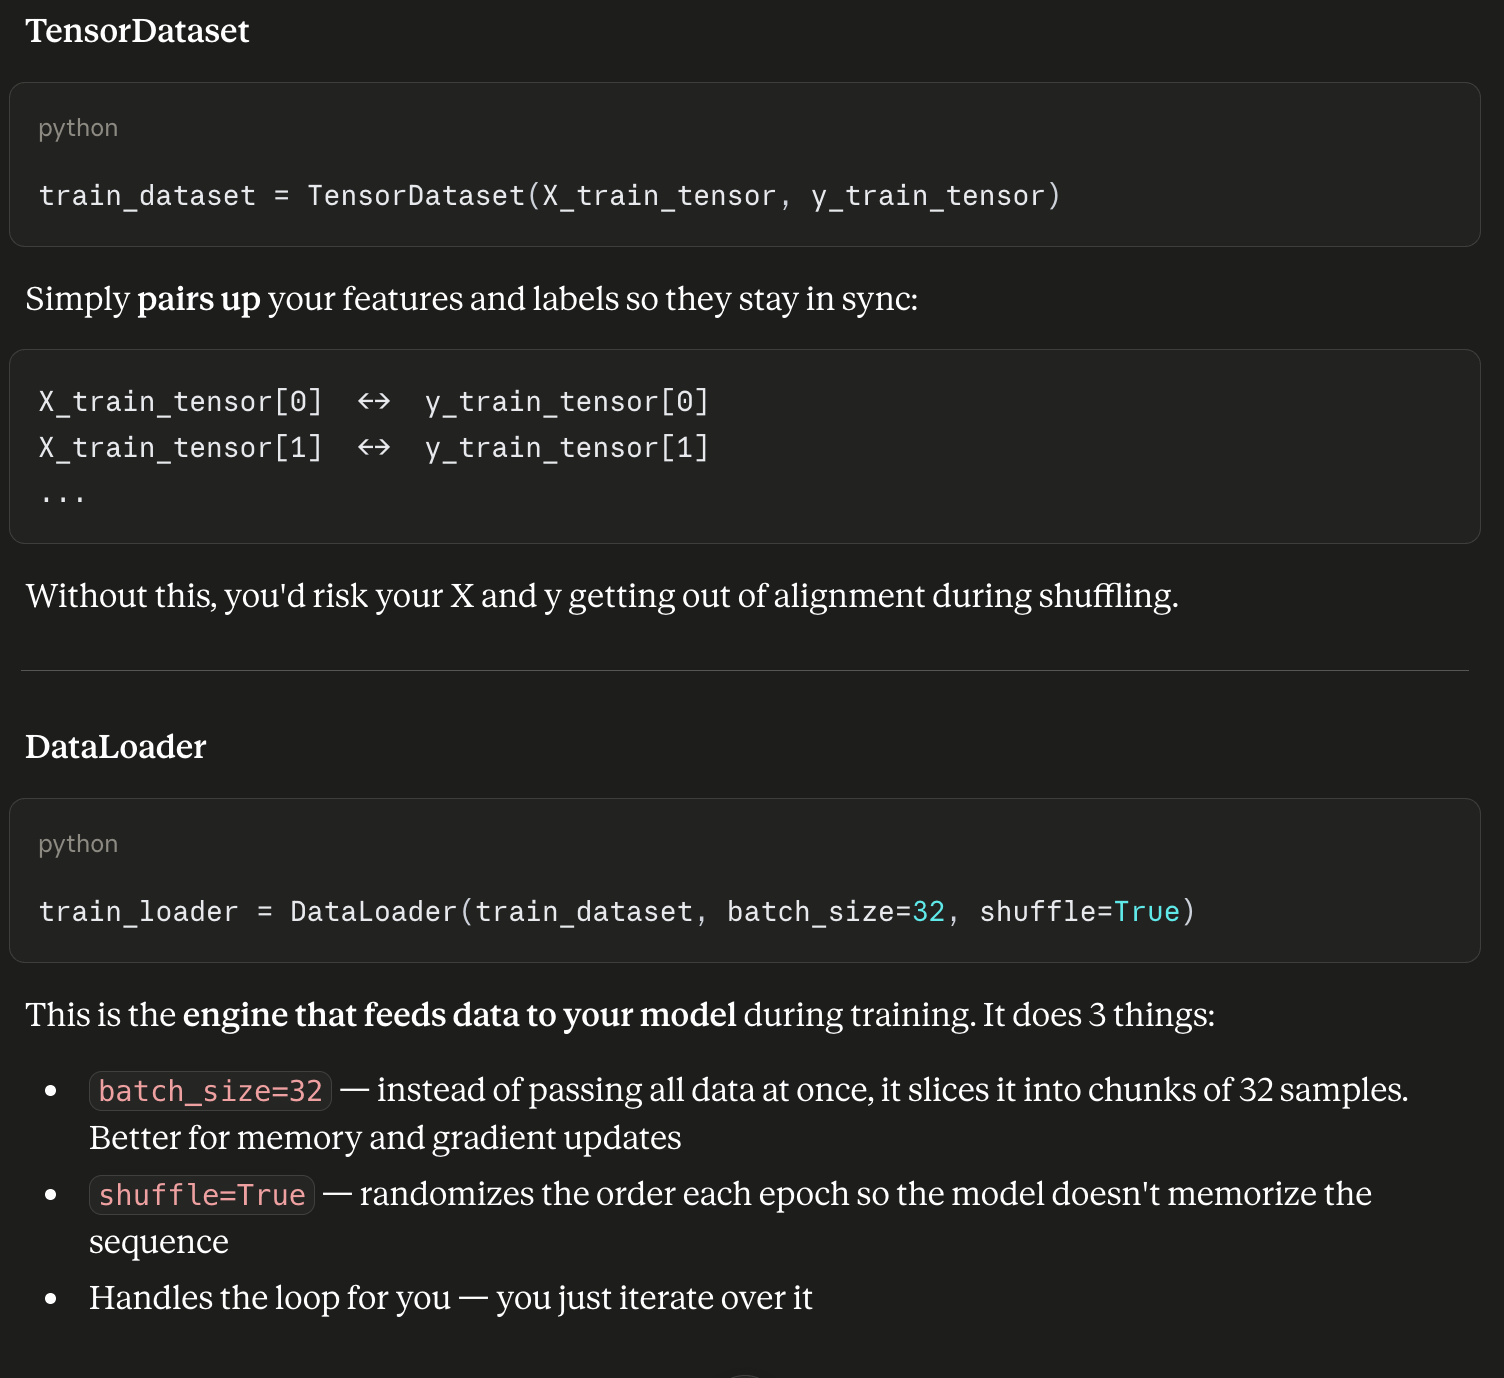

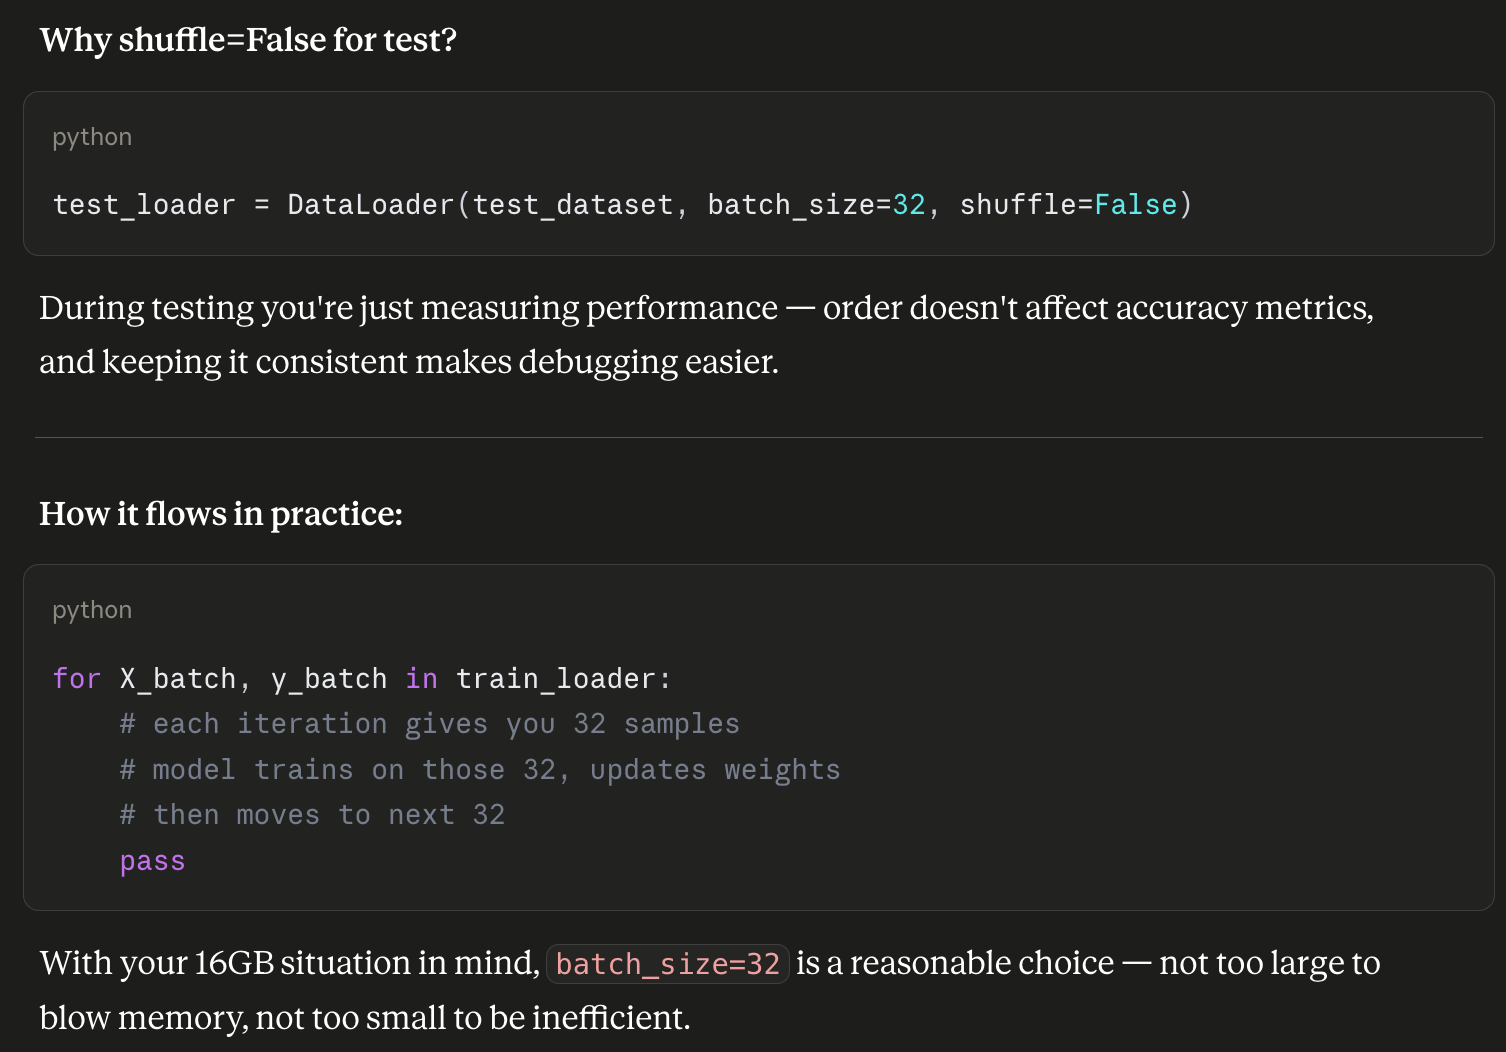

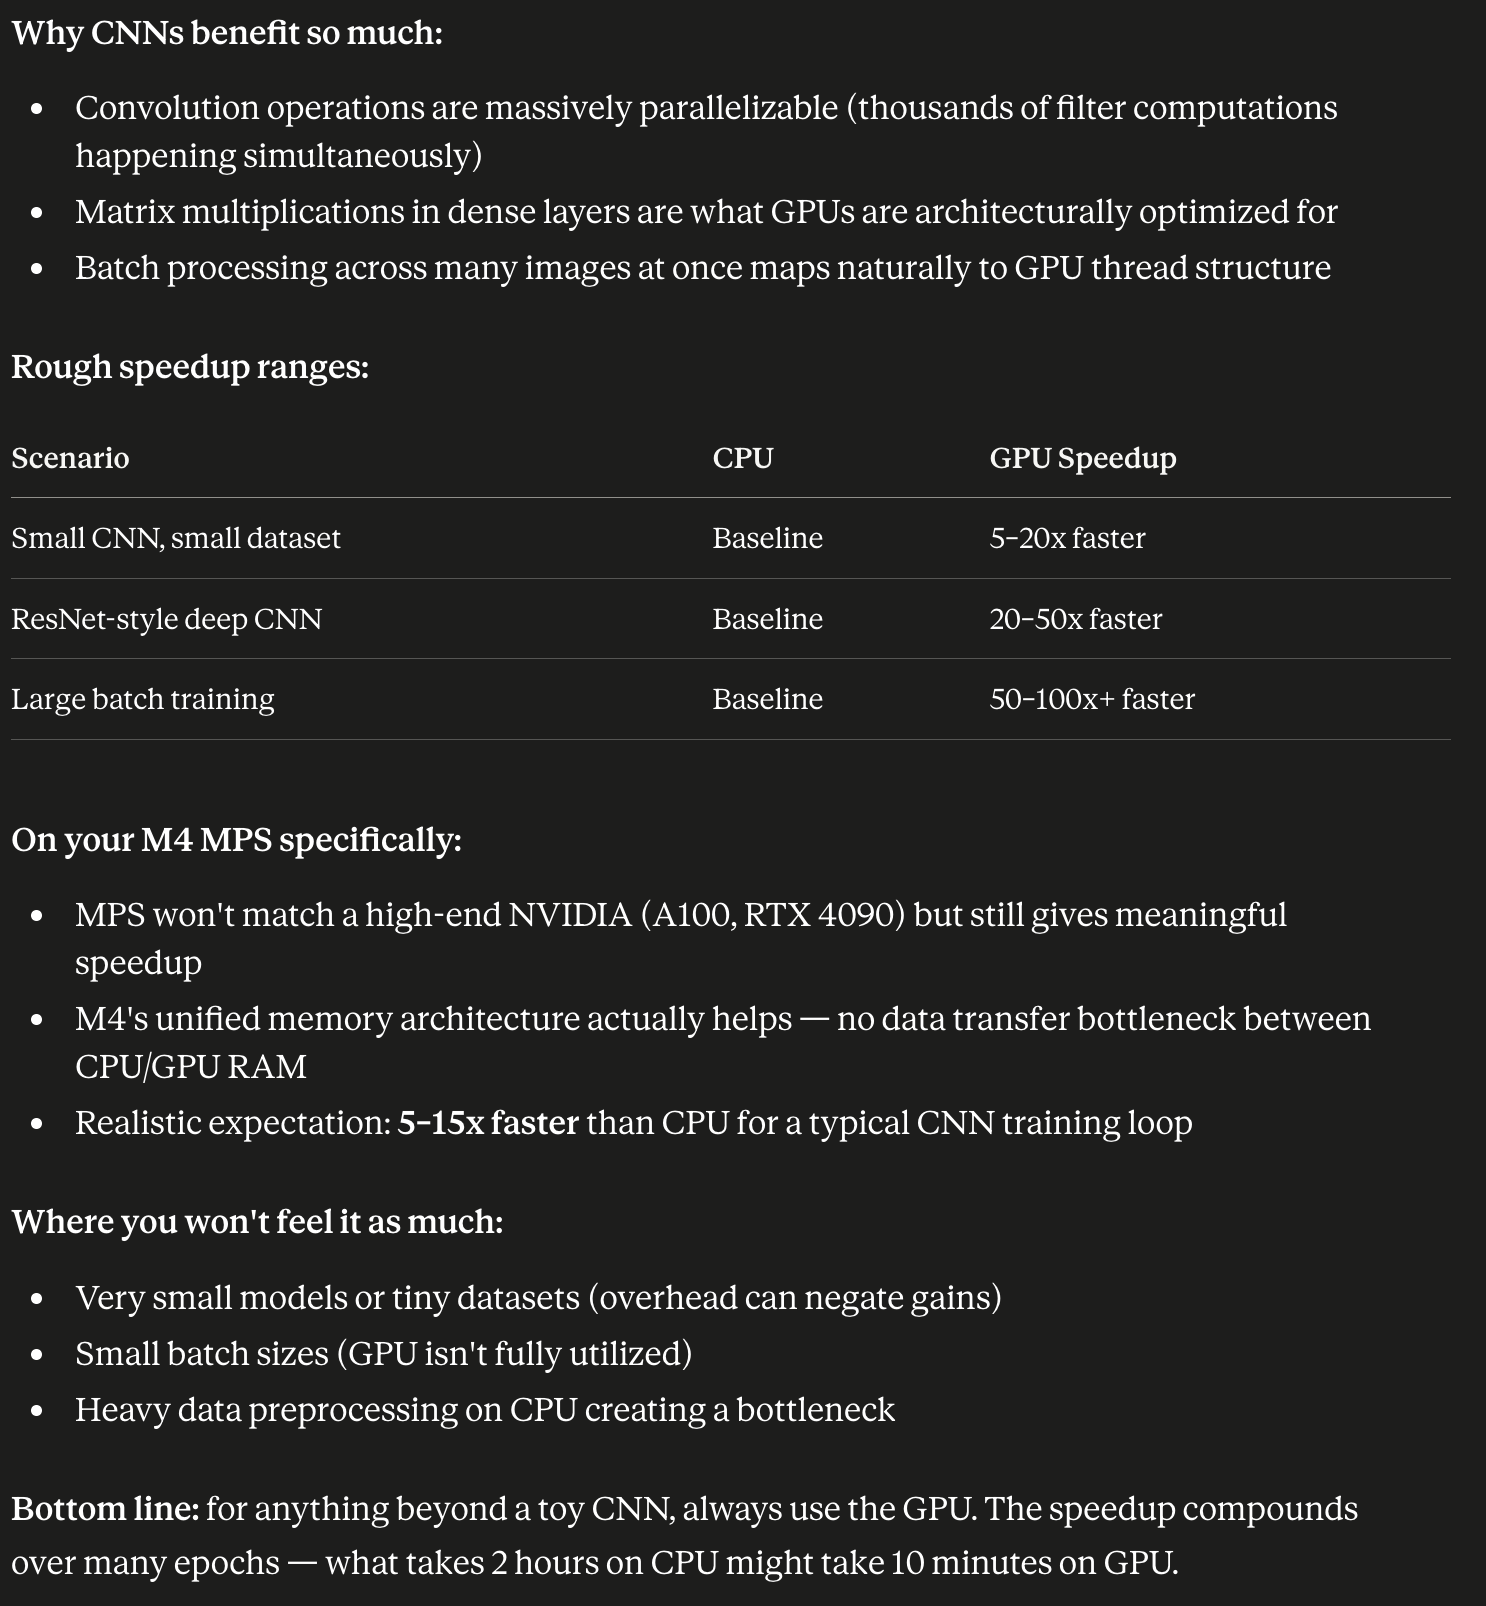